In [ ]:
!pip install tcrgnn

In [1]:
from tcrgnn import generate_edges_from_pdb_file, EdgeGenConfig

cfg = EdgeGenConfig() # You can customize the configuration if needed, but the default is what we used for our research experiments

/scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
from tcrgnn import generate_edges_from_tar,generate_edges_from_tar_dir

In [3]:
generate_edges_from_tar_dir('/scratch/project/tcr_ml/colabfold/results_2/prediction/temp_t1d','/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw',cfg)

[PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010693.tar.gz'),
 PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010694.tar.gz'),
 PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010695.tar.gz'),
 PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010696.tar.gz'),
 PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010698.tar.gz'),
 PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010699.tar.gz')]

In [4]:
from tcrgnn import load_pca_encoding
pca_encoding = load_pca_encoding("/scratch/project/tcr_ml/gnn_release/AAidx_PCA_2024.txt")
pca_encoding

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
A,-0.119337,4.766417,17.116718,2.295739,3.153466,3.641931,-2.857472,-0.510985,3.842872,-1.553891,0.760858,1.727918,2.143332,2.080794
L,17.827236,2.574882,11.241191,6.959181,-1.981687,2.180934,-0.098418,1.090348,0.559656,5.462775,7.368277,-1.595037,0.661500,0.083453
R,-8.188429,-15.255091,-1.522583,0.076711,-7.413312,-8.284450,-6.454110,-5.305068,-0.090436,-5.391594,5.400477,-1.503589,-2.789434,-0.039869
K,-11.832051,-13.376451,5.349272,1.943336,-5.254241,-2.259015,-3.690758,0.058316,-1.170751,9.122410,-4.000843,2.100945,-0.789188,3.080768
N,-15.229827,-0.084290,-3.488524,-6.198218,-1.827574,1.607748,4.176737,5.400174,-0.964957,4.007921,1.773937,-1.337021,-4.847988,-3.707884
M,16.174029,-4.974744,3.197186,-1.917002,6.432085,4.222104,-5.937735,4.277950,-0.505234,-3.175196,-3.868715,-6.915054,-2.011987,2.902042
D,-18.214603,-3.286554,-0.400137,-1.904439,4.706532,4.241386,9.203848,-2.939339,-1.991538,-2.311474,1.381515,-1.929361,-3.442823,5.299531
F,19.523669,-0.291606,-3.964076,1.787112,-2.300718,3.777835,1.369979,2.015799,-0.562367,-1.618873,3.587535,-1.685901,-0.189207,-3.736868
C,8.263782,8.355437,-5.918452,-14.414202,12.698391,-6.393775,-3.524156,-4.560058,-2.210811,4.122490,2.415289,0.575655,1.107817,-0.316855
P,-16.669545,11.992157,-16.756806,19.067663,6.366500,-0.264777,-4.297000,0.456891,-0.831621,0.545217,0.335688,0.279900,-0.296780,0.280335


In [5]:
from pathlib import Path
from tcrgnn import generate_graphs_from_edge_dir_gz, generate_graphs_from_edge_dir

base_dir = Path("/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw")

# # # Loop over all .tar.gz files
for tar_file in base_dir.glob("*.tar.gz"):
    print(f"Processing: {tar_file}")
    generate_graphs_from_edge_dir_gz(
        tar_file,
        pca_encoding,
        label=0,
        save_to_disk=True,
        filename=tar_file.with_suffix("").with_suffix("").with_suffix(".pt")
    )
# generate_graphs_from_edge_dir("/scratch/project/tcr_ml/gnn_release/temp",pca_encoding,label=0,save_to_disk=True,filename="sle_graphs.pt")

Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010695.tar.gz
Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010693.tar.gz
Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010698.tar.gz
Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010696.tar.gz
Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010699.tar.gz
Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_t1d/raw/part_table_BFI-0010694.tar.gz


In [1]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from tcrgnn import evaluate_model, load_test_file
MODEL_FILE = "MODELS/combined_bulk_single_cell_model.pt"

sle_graphs_dir = Path("test_data_v2/sle_imgt/processed")

sources, sequences, scores = [], [], []

control_files = sorted(p for p in sle_graphs_dir.iterdir() if p.is_file())

for control_file in control_files:
    control_sample_data = load_test_file(control_file)

    control_sample_scores = np.atleast_1d(
        evaluate_model(MODEL_FILE, control_sample_data)
    )

    seqs = [getattr(g, "original_characters", None) for g in control_sample_data]
    n = len(seqs)

    if len(control_sample_scores) != n:
        raise ValueError(
            f"Mismatch: {control_file.name} has {n} sequences but {len(control_sample_scores)} scores."
        )

    sequences.extend(seqs)
    scores.extend(control_sample_scores.tolist())
    sources.extend(itertools.repeat(control_file.name, n))


# build DataFrame once
control_df = pd.DataFrame(
    {"source": sources, "sequence": sequences, "scores": scores},
    copy=False,
)

print(f"{len(control_df)} sequences from {len(list(sle_graphs_dir.iterdir()))} control samples processed.")
print(control_df.head())


/scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/project_mnt/S0163/gnn_env/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


99752 sequences from 2 control samples processed.
                      source          sequence    scores
0  part_table_BFI-0009809.pt      CAWSVALNTEAF  0.999485
1  part_table_BFI-0009809.pt    CASSPPSGGRDEQF  0.919906
2  part_table_BFI-0009809.pt   CASSSNLAGARNEQF  0.291402
3  part_table_BFI-0009809.pt  CASSSAPINSANEKLF  0.001096
4  part_table_BFI-0009809.pt      CASSQDNHNEQF  0.058784


In [8]:
control_df = pd.read_csv("/scratch/project/tcr_ml/gnn_release/t1d_control_sample_scores.csv")

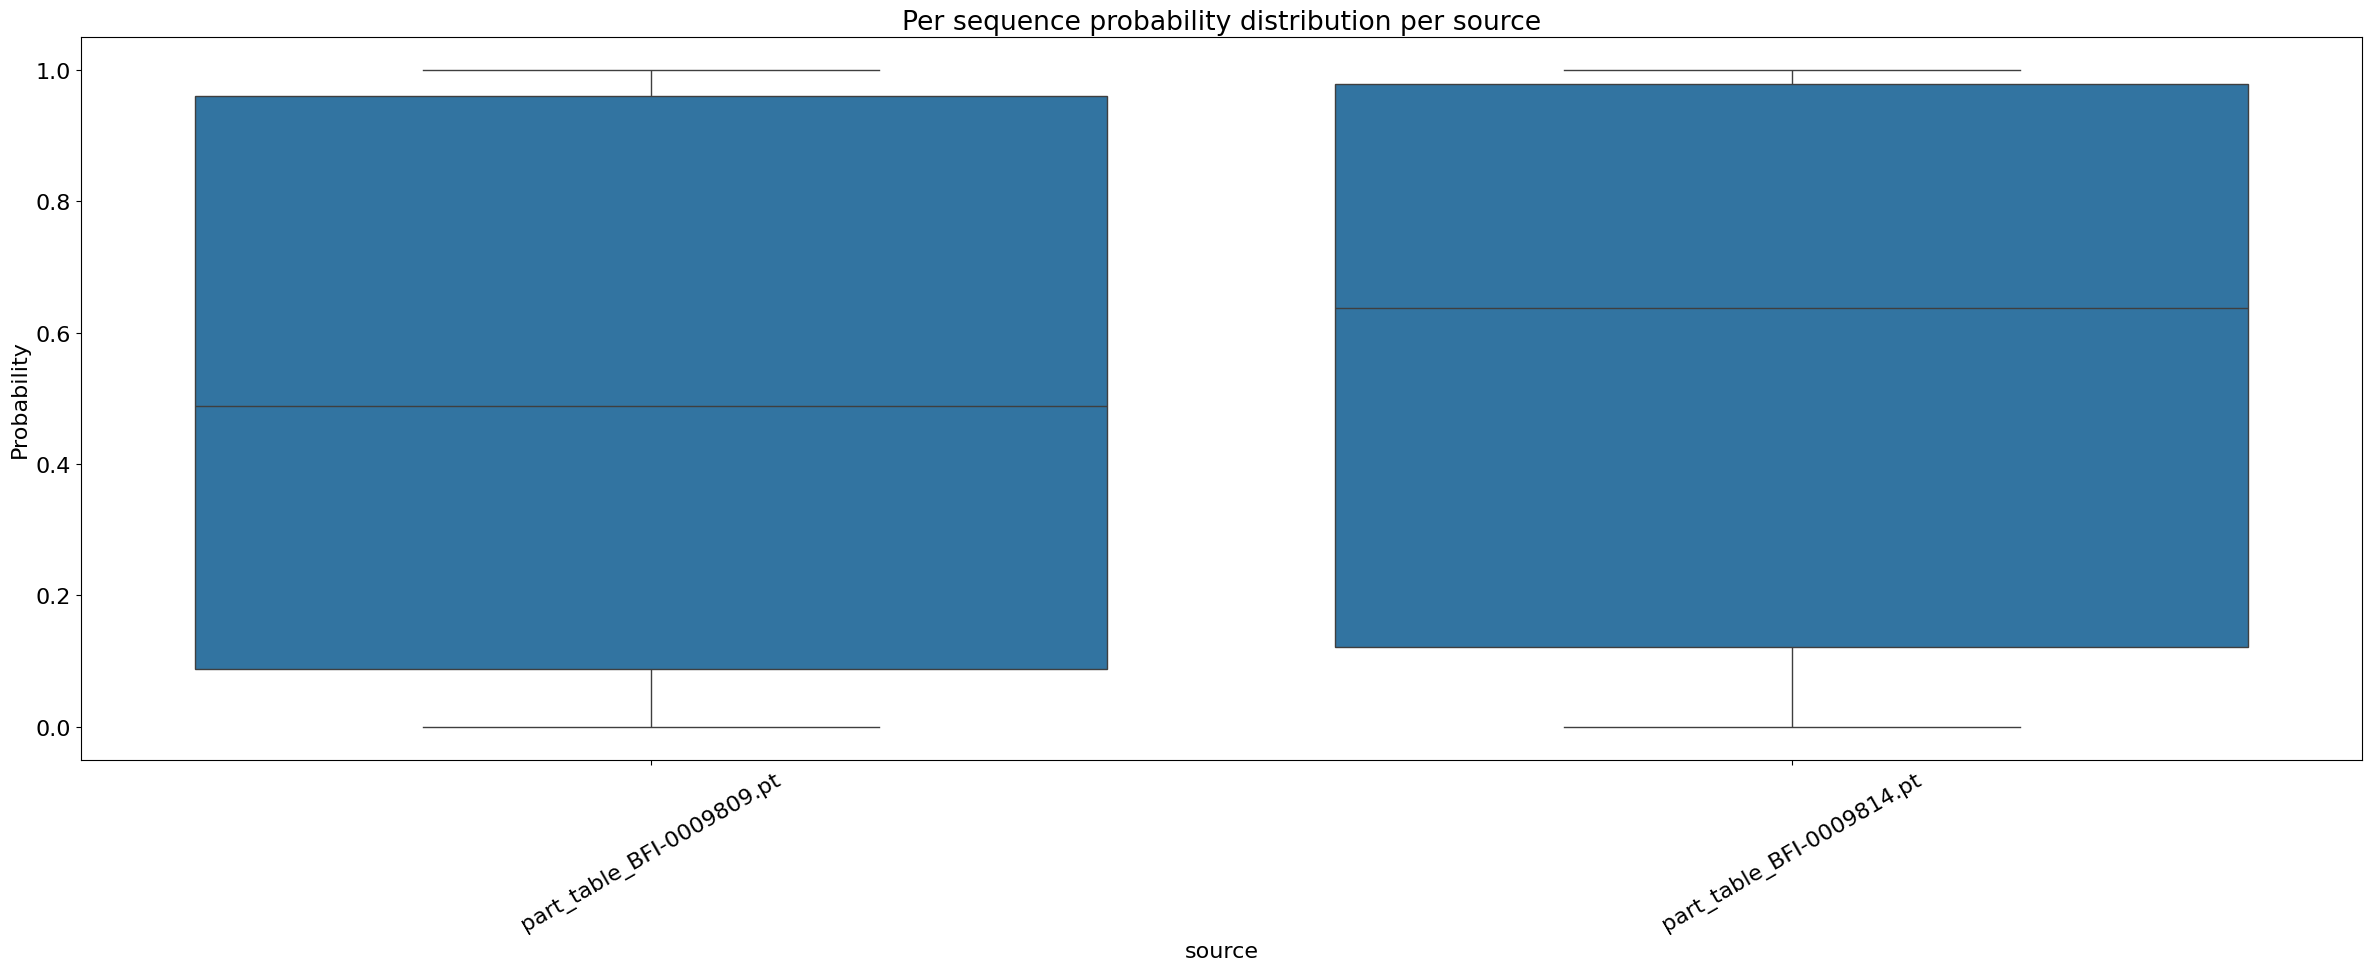

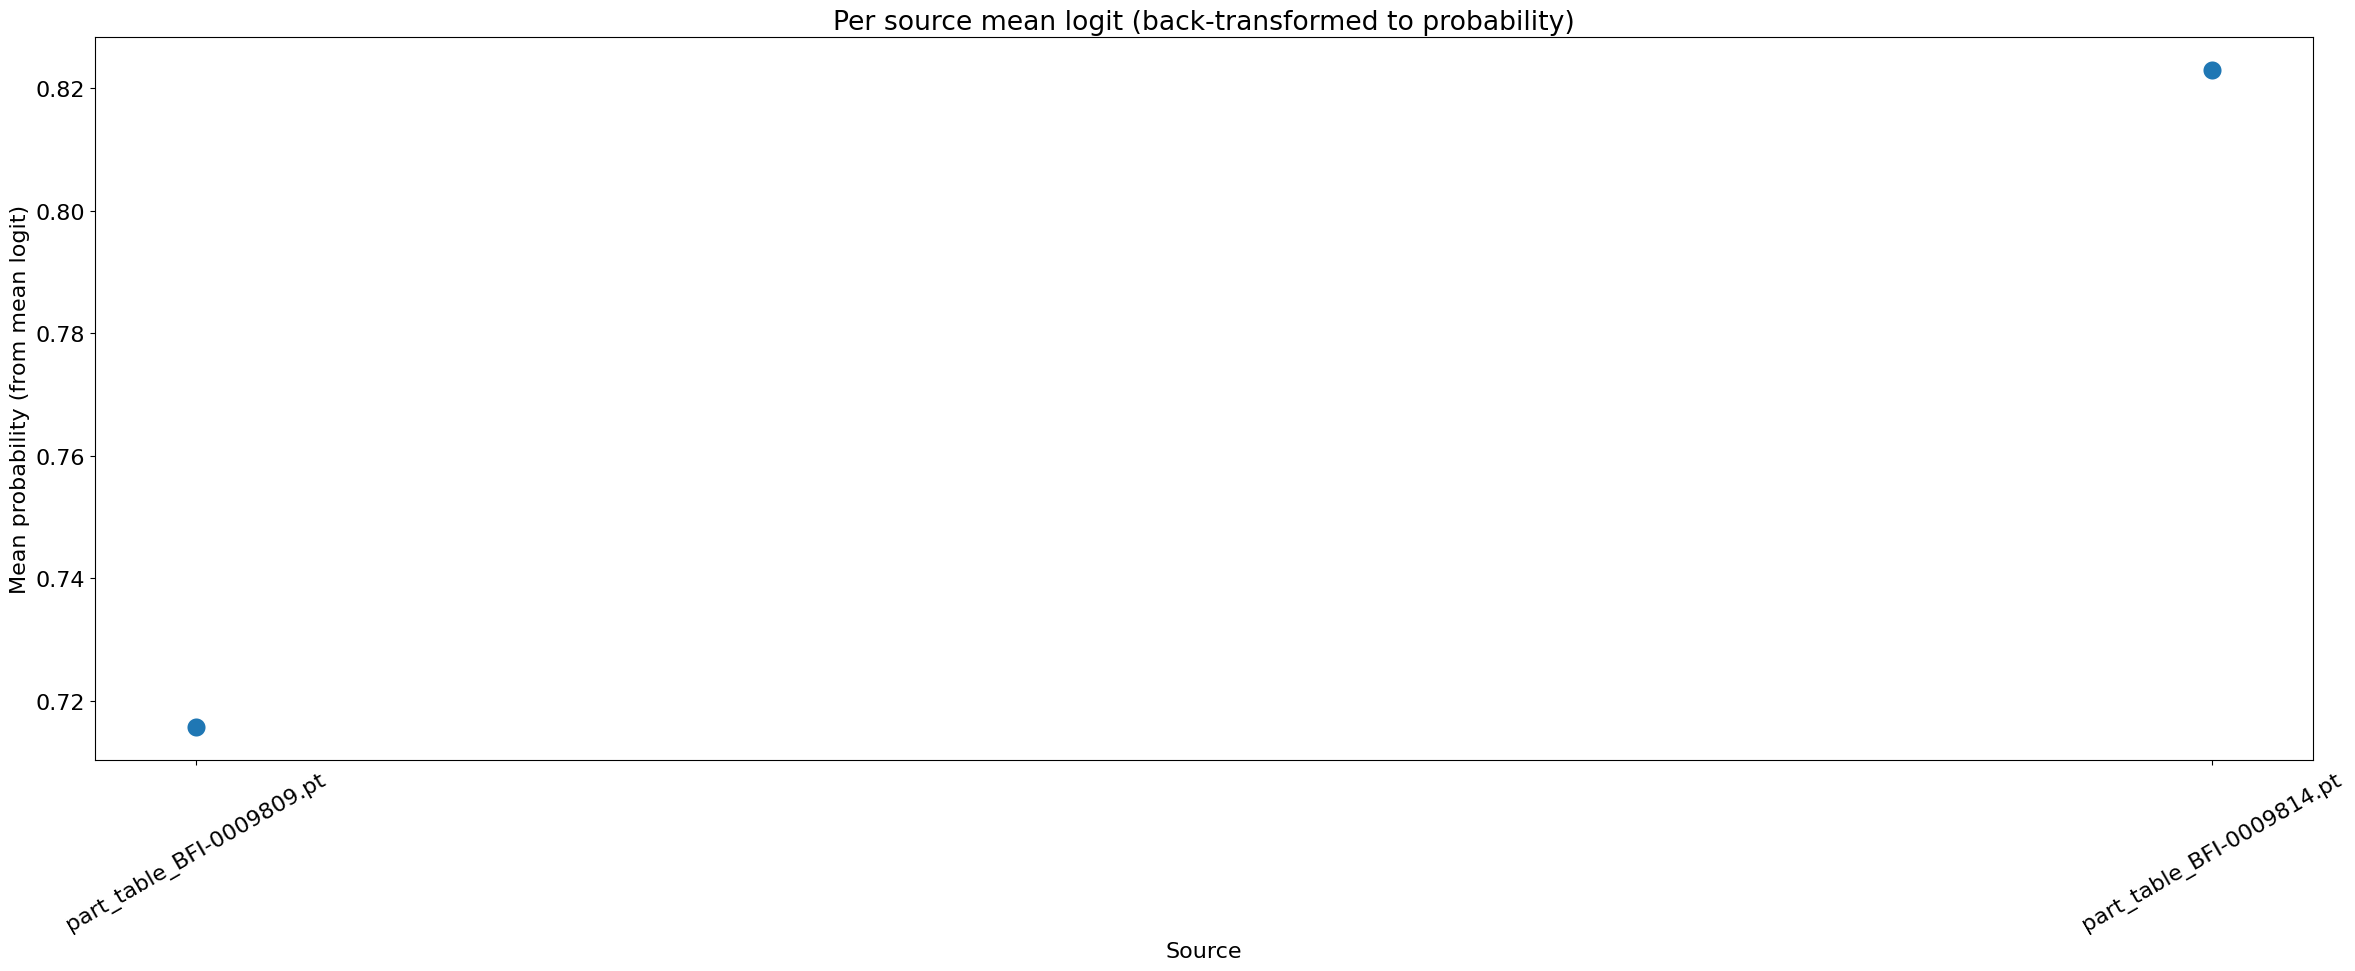

,source,inv_logit_mean
0,part_table_BFI-0009809.pt,0.715770
1,part_table_BFI-0009814.pt,0.822902


In [2]:
from tcrgnn import plot_inv_logit_per_source
summary_control_df = plot_inv_logit_per_source(control_df)
summary_control_df